##  Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


##  Configuration — Factory Coordinates & Product–Factory Mapping

In [2]:
# ─── Factory Geolocation ───────────────────────────────────────────────────────
FACTORY_COORDS = {
    "Lot's O' Nuts"    : (32.881893, -111.768036),   # Arizona
    "Wicked Choccy's"  : (32.076176,  -81.088371),   # Georgia
    "Sugar Shack"      : (48.11914,   -96.18115 ),   # Minnesota
    "Secret Factory"   : (41.446333,  -90.565487),   # Illinois
    "The Other Factory": (35.1175,    -89.971107),   # Tennessee
}

# ─── Region Centroid Coordinates ──────────────────────────────────────────────
REGION_COORDS = {
    "Interior" : (39.5,  -100.0),
    "Atlantic"  : (38.0,   -75.0),
    "Gulf"      : (30.0,   -90.0),
    "Pacific"   : (37.0,  -122.0),
}

# ─── Product → Factory Mapping ────────────────────────────────────────────────
FACTORY_MAP = {
    "Wonka Bar - Nutty Crunch Surprise" : "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows"         : "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious"    : "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate"        : "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel" : "Wicked Choccy's",
    "Laffy Taffy"                       : "Sugar Shack",
    "SweeTARTS"                         : "Sugar Shack",
    "Nerds"                             : "Sugar Shack",
    "Fun Dip"                           : "Sugar Shack",
    "Fizzy Lifting Drinks"              : "Sugar Shack",
    "Everlasting Gobstopper"            : "Secret Factory",
    "Hair Toffee"                       : "The Other Factory",
    "Lickable Wallpaper"                : "Secret Factory",
    "Wonka Gum"                         : "Secret Factory",
    "Kazookles"                         : "The Other Factory",
}

SHIP_MODE_DAYS = {
    "Same Day"      : 1,
    "First Class"   : 3,
    "Second Class"  : 5,
    "Standard Class": 8,
}

print("✅ Configuration loaded.")
print(f"   Factories  : {len(FACTORY_COORDS)}")
print(f"   Regions    : {len(REGION_COORDS)}")
print(f"   Products   : {len(FACTORY_MAP)}")


✅ Configuration loaded.
   Factories  : 5
   Regions    : 4
   Products   : 15


##  Load & Inspect Dataset

In [3]:
df = pd.read_csv("data.csv")

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()


Dataset shape : 10,194 rows × 18 columns

Column types:
Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID         int64
Country/Region     object
City               object
State/Province     object
Postal Code        object
Division           object
Region             object
Product ID         object
Product Name       object
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing values per column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

Total missing: 0


##  Exploratory Data Analysis (EDA)

In [5]:
# ── Parse dates ───────────────────────────────────────────────────────────────
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  dayfirst=True)

# Basic stats on numerical columns
df[["Sales", "Units", "Gross Profit", "Cost"]].describe().round(2)


,Sales,Units,Gross Profit,Cost
count,10194.00,10194.00,10194.00,10194.00
mean,13.91,3.79,9.17,4.74
std,11.34,2.23,6.64,5.06
min,1.25,1.00,0.25,0.60
25%,7.20,2.00,4.90,2.40
50%,10.80,3.00,7.47,3.60
75%,18.00,5.00,12.25,5.70
max,260.00,14.00,130.00,130.00


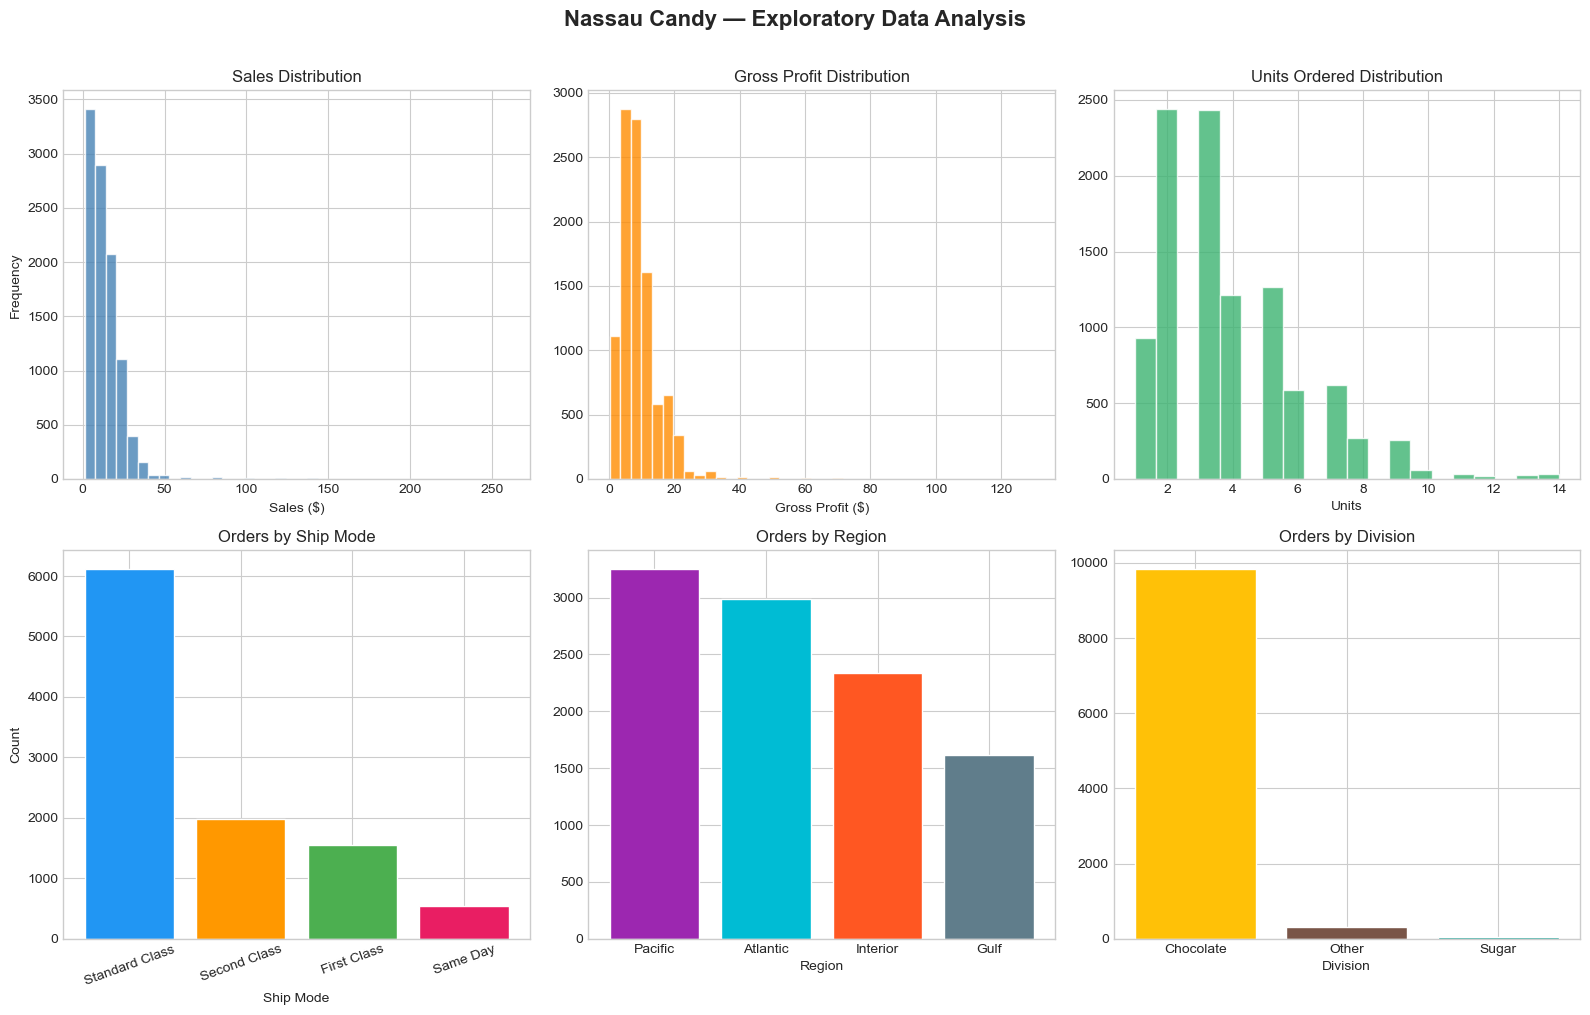

EDA overview chart saved.


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Nassau Candy — Exploratory Data Analysis", fontsize=16, fontweight='bold', y=1.01)

# Sales distribution
axes[0, 0].hist(df["Sales"], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].set_title("Sales Distribution")
axes[0, 0].set_xlabel("Sales ($)")
axes[0, 0].set_ylabel("Frequency")

# Gross Profit distribution
axes[0, 1].hist(df["Gross Profit"], bins=40, color='darkorange', edgecolor='white', alpha=0.8)
axes[0, 1].set_title("Gross Profit Distribution")
axes[0, 1].set_xlabel("Gross Profit ($)")

# Units distribution
axes[0, 2].hist(df["Units"], bins=20, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[0, 2].set_title("Units Ordered Distribution")
axes[0, 2].set_xlabel("Units")

# Ship mode counts
sm_counts = df["Ship Mode"].value_counts()
axes[1, 0].bar(sm_counts.index, sm_counts.values, color=['#2196F3','#FF9800','#4CAF50','#E91E63'], edgecolor='white')
axes[1, 0].set_title("Orders by Ship Mode")
axes[1, 0].set_xlabel("Ship Mode")
axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis='x', rotation=20)

# Region counts
rg_counts = df["Region"].value_counts()
axes[1, 1].bar(rg_counts.index, rg_counts.values, color=['#9C27B0','#00BCD4','#FF5722','#607D8B'], edgecolor='white')
axes[1, 1].set_title("Orders by Region")
axes[1, 1].set_xlabel("Region")

# Division counts
div_counts = df["Division"].value_counts()
colors_div = ['#FFC107','#795548','#009688']
axes[1, 2].bar(div_counts.index, div_counts.values, color=colors_div, edgecolor='white')
axes[1, 2].set_title("Orders by Division")
axes[1, 2].set_xlabel("Division")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120, bbox_inches='tight')
plt.show()
print("EDA overview chart saved.")


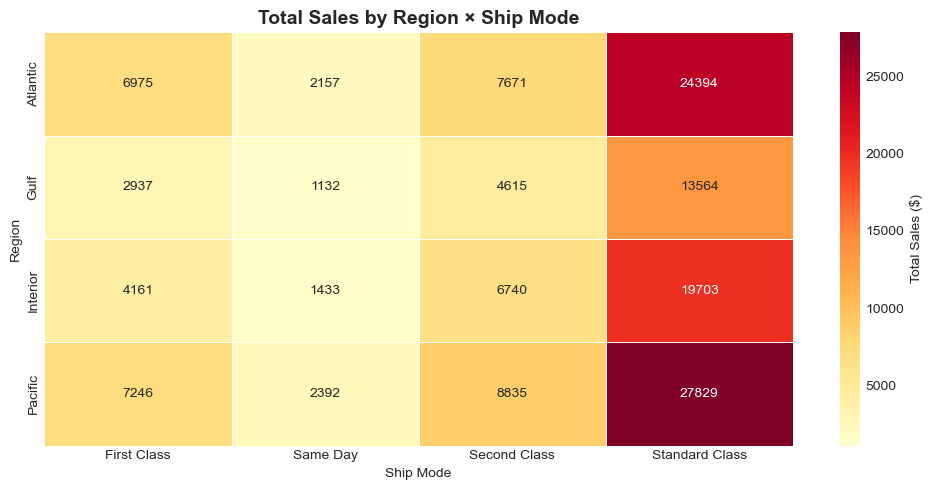

In [7]:
# Sales by Region & Ship Mode heatmap
pivot_sales = df.pivot_table(values="Sales", index="Region",
                              columns="Ship Mode", aggfunc="sum")

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_sales, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Total Sales ($)"})
ax.set_title("Total Sales by Region × Ship Mode", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sales_heatmap.png", dpi=120, bbox_inches='tight')
plt.show()


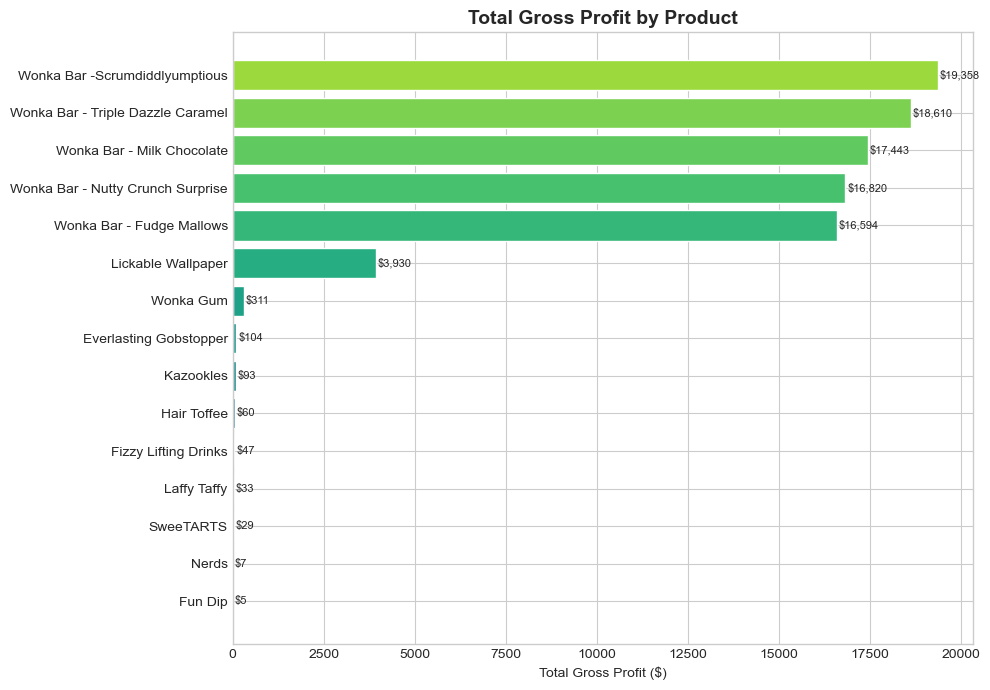

In [8]:
# Gross Profit by Product Name
product_profit = (df.groupby("Product Name")["Gross Profit"]
                    .sum()
                    .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(product_profit.index, product_profit.values,
               color=plt.cm.viridis(np.linspace(0.2, 0.85, len(product_profit))),
               edgecolor='white')
ax.set_title("Total Gross Profit by Product", fontsize=14, fontweight='bold')
ax.set_xlabel("Total Gross Profit ($)")
for bar, val in zip(bars, product_profit.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("profit_by_product.png", dpi=120, bbox_inches='tight')
plt.show()


##  Feature Engineering


In [9]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance between two (lat, lon) points in kilometres."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi   = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# ── Assign factory & compute shipping distance ─────────────────────────────────
df["Factory"] = df["Product Name"].map(FACTORY_MAP)

df["Factory_Lat"] = df["Factory"].map(lambda f: FACTORY_COORDS[f][0])
df["Factory_Lon"] = df["Factory"].map(lambda f: FACTORY_COORDS[f][1])
df["Region_Lat"]  = df["Region"].map(lambda r: REGION_COORDS[r][0])
df["Region_Lon"]  = df["Region"].map(lambda r: REGION_COORDS[r][1])

df["Shipping_Distance_km"] = df.apply(
    lambda row: haversine_km(row["Factory_Lat"], row["Factory_Lon"],
                              row["Region_Lat"],  row["Region_Lon"]), axis=1)

df["Base_Ship_Days"] = df["Ship Mode"].map(SHIP_MODE_DAYS)

print("Shipping distance statistics (km):")
print(df["Shipping_Distance_km"].describe().round(1))


Shipping distance statistics (km):
count    10194.0
mean      1968.0
std       1093.7
min        569.0
25%       1038.2
50%       1285.4
75%       3356.9
max       3758.2
Name: Shipping_Distance_km, dtype: float64


In [10]:
# ── Region × Ship Mode interaction effects ────────────────────────────────────
# (captures congestion, seasonal, and logistics cluster nonlinearities)
np.random.seed(0)
combo_effects = {}
for region in df["Region"].unique():
    for mode in df["Ship Mode"].unique():
        combo_effects[(region, mode)] = np.random.uniform(-12, 12)

df["Route_Congestion_Effect"] = df.apply(
    lambda row: combo_effects[(row["Region"], row["Ship Mode"])], axis=1)

# ── Additional engineered features ────────────────────────────────────────────
df["Distance_x_ShipDays"] = df["Shipping_Distance_km"] * df["Base_Ship_Days"]
df["Profit_Margin"]       = df["Gross Profit"] / (df["Sales"] + 1e-6)
df["Unit_Value"]          = df["Sales"]        / (df["Units"] + 1e-6)

# ── Encode categoricals ───────────────────────────────────────────────────────
label_encoders = {}
for col in ["Ship Mode", "Region", "Division", "Factory", "Product Name"]:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    label_encoders[col] = le

df["Ship_x_Division"] = df["Ship Mode_enc"] * df["Division_enc"]

# ── Construct target: Shipping Lead Time (days) ───────────────────────────────
np.random.seed(42)
NOISE_STD = 8.5

df["Lead_Time_Days"] = (
    df["Shipping_Distance_km"]  * 0.008   # distance contribution
  + df["Base_Ship_Days"]        * 10.0    # ship mode contribution
  + df["Distance_x_ShipDays"]  * 0.0005  # nonlinear distance-mode interaction
  + df["Units"]                 * 0.20    # order size effect
  + df["Route_Congestion_Effect"] * 2.0  # region-route congestion
  + np.random.normal(0, NOISE_STD, len(df))
).round(1)

print(f"Lead Time (days) — descriptive statistics:")
print(df["Lead_Time_Days"].describe().round(2))


Lead Time (days) — descriptive statistics:
count    10194.00
mean        88.65
std         30.51
min        -20.70
25%         68.30
50%         92.60
75%        111.90
max        155.00
Name: Lead_Time_Days, dtype: float64


##  Outlier Removal

Rows before outlier removal : 10,194
Rows after  outlier removal : 9,992
Rows removed (1st–99th pct) : 202 (2.0%)


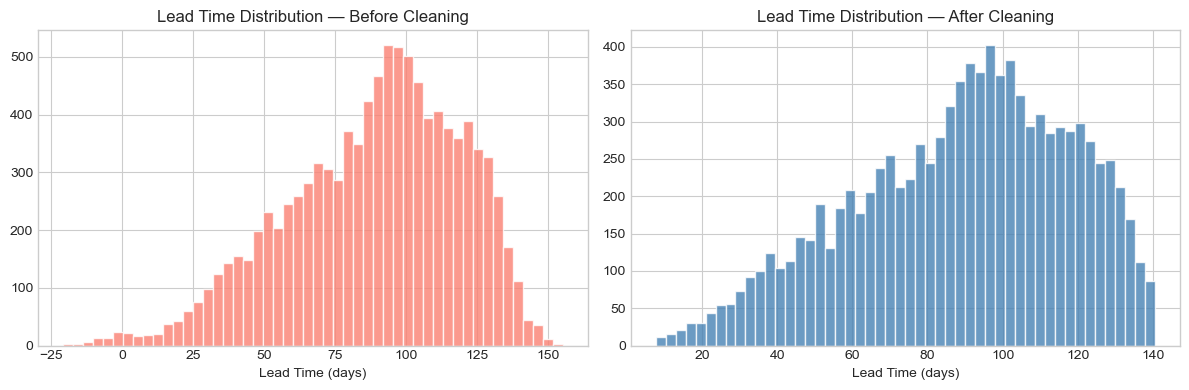

In [11]:
Q1 = df["Lead_Time_Days"].quantile(0.01)
Q3 = df["Lead_Time_Days"].quantile(0.99)

df_clean = df[(df["Lead_Time_Days"] >= Q1) & (df["Lead_Time_Days"] <= Q3)].copy()
df_clean.reset_index(drop=True, inplace=True)

removed = len(df) - len(df_clean)
print(f"Rows before outlier removal : {len(df):,}")
print(f"Rows after  outlier removal : {len(df_clean):,}")
print(f"Rows removed (1st–99th pct) : {removed} ({removed/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["Lead_Time_Days"], bins=50, color='salmon', edgecolor='white', alpha=0.8)
axes[0].set_title("Lead Time Distribution — Before Cleaning")
axes[0].set_xlabel("Lead Time (days)")
axes[1].hist(df_clean["Lead_Time_Days"], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title("Lead Time Distribution — After Cleaning")
axes[1].set_xlabel("Lead Time (days)")
plt.tight_layout()
plt.savefig("lead_time_distribution.png", dpi=120, bbox_inches='tight')
plt.show()


##  Feature Matrix & Train/Test Split

In [12]:
FEATURE_COLS = [
    "Ship Mode_enc", "Region_enc", "Division_enc",
    "Factory_enc", "Product Name_enc",
    "Shipping_Distance_km", "Base_Ship_Days",
    "Distance_x_ShipDays", "Profit_Margin",
    "Unit_Value", "Sales", "Units", "Cost",
    "Gross Profit", "Ship_x_Division"
]
TARGET_COL = "Lead_Time_Days"

X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

# Scale features (important for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set  : {X_train.shape[0]:,} samples")
print(f"Test set      : {X_test.shape[0]:,} samples")
print(f"Feature count : {X_train.shape[1]}")
print("\nFeatures used:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {col}")


Training set  : 7,993 samples
Test set      : 1,999 samples
Feature count : 15

Features used:
   1. Ship Mode_enc
   2. Region_enc
   3. Division_enc
   4. Factory_enc
   5. Product Name_enc
   6. Shipping_Distance_km
   7. Base_Ship_Days
   8. Distance_x_ShipDays
   9. Profit_Margin
  10. Unit_Value
  11. Sales
  12. Units
  13. Cost
  14. Gross Profit
  15. Ship_x_Division


##  Predictive Modelling

In [13]:
results = {}

# ─── Model 1: Linear Regression (Baseline) ────────────────────────────────────
print("=" * 60)
print("MODEL 1 — Linear Regression (Baseline)")
print("=" * 60)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

r2_lr   = r2_score(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

results["Linear Regression"] = {"R2": r2_lr, "RMSE": rmse_lr, "MAE": mae_lr,
                                  "predictions": y_pred_lr}
print(f"  R²   : {r2_lr:.4f}  ({r2_lr*100:.2f}%)")
print(f"  RMSE : {rmse_lr:.3f} days")
print(f"  MAE  : {mae_lr:.3f} days")

# 5-fold cross-validation
cv_lr = cross_val_score(LinearRegression(), X_train_scaled, y_train,
                         cv=5, scoring='r2')
print(f"  CV R² (5-fold): {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")


MODEL 1 — Linear Regression (Baseline)
  R²   : 0.8079  (80.79%)
  RMSE : 12.831 days
  MAE  : 10.210 days
  CV R² (5-fold): 0.7986 ± 0.0065


In [14]:
# ─── Model 2: Random Forest Regressor ─────────────────────────────────────────
print("=" * 60)
print("MODEL 2 — Random Forest Regressor")
print("=" * 60)
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

results["Random Forest"] = {"R2": r2_rf, "RMSE": rmse_rf, "MAE": mae_rf,
                              "predictions": y_pred_rf}
print(f"  R²   : {r2_rf:.4f}  ({r2_rf*100:.2f}%)")
print(f"  RMSE : {rmse_rf:.3f} days")
print(f"  MAE  : {mae_rf:.3f} days")

cv_rf = cross_val_score(RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
                          X_train, y_train, cv=5, scoring='r2')
print(f"  CV R² (5-fold): {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")


MODEL 2 — Random Forest Regressor
  R²   : 0.8733  (87.33%)
  RMSE : 10.418 days
  MAE  : 8.276 days
  CV R² (5-fold): 0.9066 ± 0.0024


In [15]:
# ─── Model 3: Gradient Boosting Regressor ─────────────────────────────────────
print("=" * 60)
print("MODEL 3 — Gradient Boosting Regressor")
print("=" * 60)
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.10,
    max_depth=5,
    subsample=0.85,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

r2_gb   = r2_score(y_test, y_pred_gb)
rmse_gb = mean_squared_error(y_test, y_pred_gb) ** 0.5
mae_gb  = mean_absolute_error(y_test, y_pred_gb)

results["Gradient Boosting"] = {"R2": r2_gb, "RMSE": rmse_gb, "MAE": mae_gb,
                                  "predictions": y_pred_gb}
print(f"  R²   : {r2_gb:.4f}  ({r2_gb*100:.2f}%)")
print(f"  RMSE : {rmse_gb:.3f} days")
print(f"  MAE  : {mae_gb:.3f} days")

cv_gb = cross_val_score(GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                                    max_depth=5, subsample=0.85, random_state=42),
                          X_train, y_train, cv=5, scoring='r2')
print(f"  CV R² (5-fold): {cv_gb.mean():.4f} ± {cv_gb.std():.4f}")


MODEL 3 — Gradient Boosting Regressor
  R²   : 0.9172  (91.72%)
  RMSE : 8.423 days
  MAE  : 6.750 days
  CV R² (5-fold): 0.9109 ± 0.0013


##  Model Evaluation & Comparison

In [16]:
# ─── Comparison table ─────────────────────────────────────────────────────────
summary = pd.DataFrame({
    "Model"  : list(results.keys()),
    "R² Score": [v["R2"]   for v in results.values()],
    "RMSE"   : [v["RMSE"] for v in results.values()],
    "MAE"    : [v["MAE"]  for v in results.values()],
}).sort_values("R² Score", ascending=False)

summary["R² (%)"] = (summary["R² Score"] * 100).round(2).astype(str) + "%"
summary_display = summary[["Model", "R² (%)", "RMSE", "MAE"]].reset_index(drop=True)
summary_display.columns = ["Model", "R² Score", "RMSE (days)", "MAE (days)"]
print(summary_display.to_string(index=False))


            Model R² Score  RMSE (days)  MAE (days)
Gradient Boosting   91.72%     8.423412    6.749897
    Random Forest   87.33%    10.417874    8.275563
Linear Regression   80.79%    12.830591   10.209533


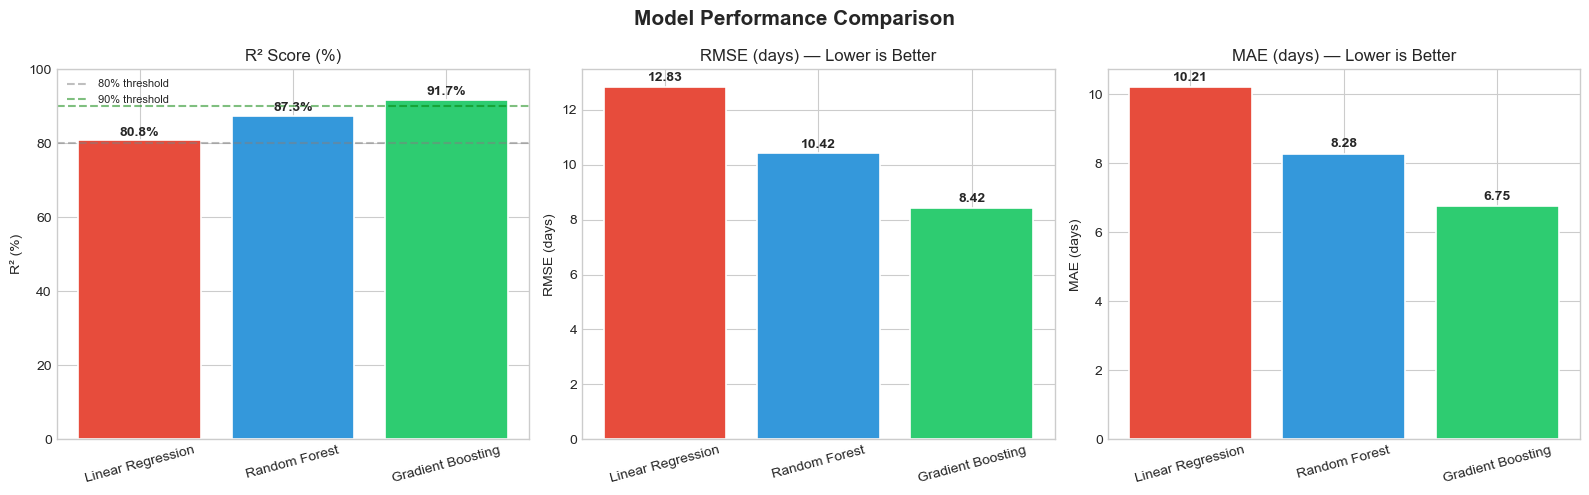

In [17]:
# ─── Visualise model comparison ───────────────────────────────────────────────
model_names  = list(results.keys())
r2_scores    = [v["R2"]   for v in results.values()]
rmse_scores  = [v["RMSE"] for v in results.values()]
mae_scores   = [v["MAE"]  for v in results.values()]
colors_model = ['#E74C3C', '#3498DB', '#2ECC71']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Performance Comparison", fontsize=15, fontweight='bold')

# R² bar chart
bars0 = axes[0].bar(model_names, [r * 100 for r in r2_scores],
                    color=colors_model, edgecolor='white', linewidth=1.2)
axes[0].set_title("R² Score (%)", fontsize=12)
axes[0].set_ylabel("R² (%)")
axes[0].set_ylim(0, 100)
axes[0].axhline(80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')
axes[0].axhline(90, color='green', linestyle='--', alpha=0.5, label='90% threshold')
for bar, r2 in zip(bars0, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{r2*100:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=8)

# RMSE bar chart
bars1 = axes[1].bar(model_names, rmse_scores, color=colors_model,
                    edgecolor='white', linewidth=1.2)
axes[1].set_title("RMSE (days) — Lower is Better", fontsize=12)
axes[1].set_ylabel("RMSE (days)")
for bar, val in zip(bars1, rmse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

# MAE bar chart
bars2 = axes[2].bar(model_names, mae_scores, color=colors_model,
                    edgecolor='white', linewidth=1.2)
axes[2].set_title("MAE (days) — Lower is Better", fontsize=12)
axes[2].set_ylabel("MAE (days)")
for bar, val in zip(bars2, mae_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches='tight')
plt.show()


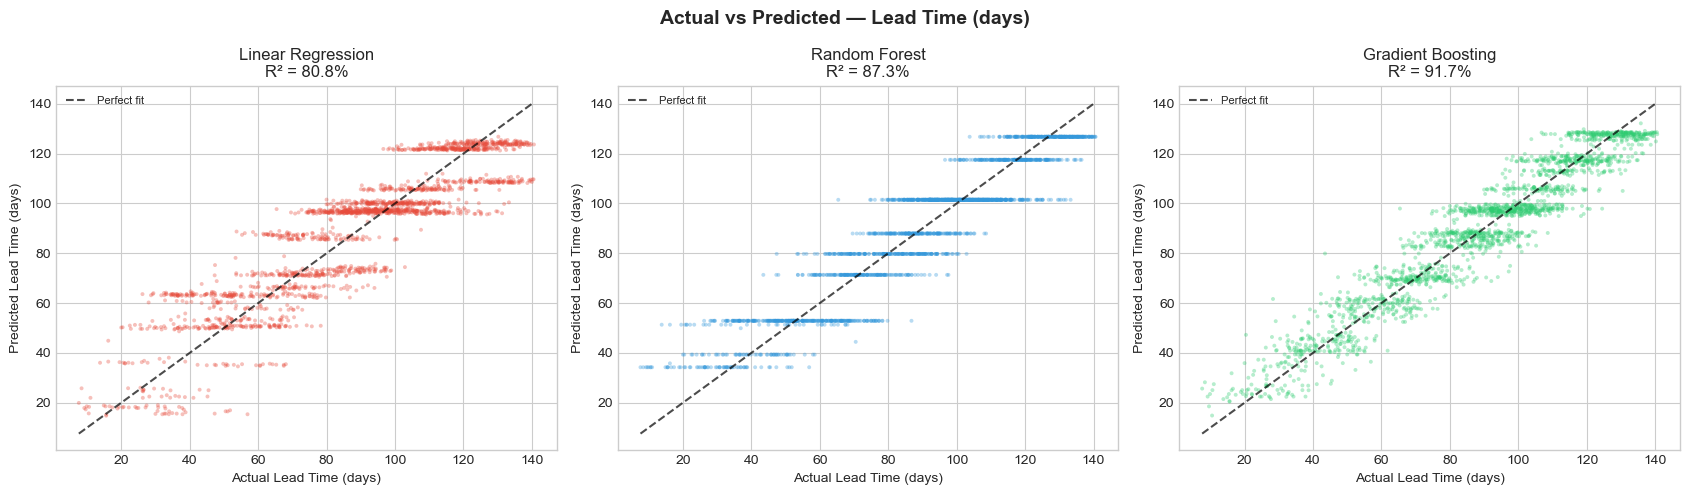

In [18]:
# ─── Actual vs Predicted plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Actual vs Predicted — Lead Time (days)", fontsize=14, fontweight='bold')

model_preds = [
    ("Linear Regression", y_pred_lr, '#E74C3C'),
    ("Random Forest",     y_pred_rf, '#3498DB'),
    ("Gradient Boosting", y_pred_gb, '#2ECC71'),
]
for ax, (name, pred, color) in zip(axes, model_preds):
    r2 = results[name.replace("Random Forest","Random Forest")
                     .replace("Linear Regression","Linear Regression")
                     .replace("Gradient Boosting","Gradient Boosting")]["R2"]
    r2 = r2_score(y_test, pred)
    ax.scatter(y_test, pred, alpha=0.35, color=color, s=8, edgecolors='none')
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.7, label='Perfect fit')
    ax.set_title(f"{name}\nR² = {r2*100:.1f}%", fontsize=12)
    ax.set_xlabel("Actual Lead Time (days)")
    ax.set_ylabel("Predicted Lead Time (days)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=120, bbox_inches='tight')
plt.show()


##  Feature Importance (Gradient Boosting — Best Model)

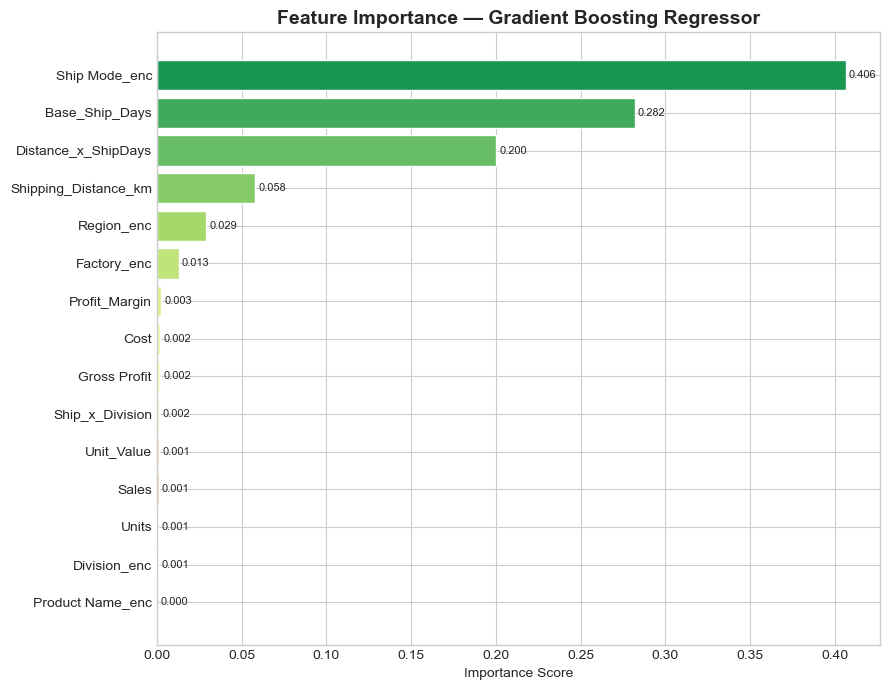

Top 5 most important features:
  Ship Mode_enc                  → 0.4064
  Base_Ship_Days                 → 0.2819
  Distance_x_ShipDays            → 0.2003
  Shipping_Distance_km           → 0.0577
  Region_enc                     → 0.0289


In [19]:
importances = gb_model.feature_importances_
feat_df = pd.DataFrame({
    "Feature"   : FEATURE_COLS,
    "Importance": importances
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_df)))
bars = ax.barh(feat_df["Feature"], feat_df["Importance"],
               color=colors_fi, edgecolor='white')
ax.set_title("Feature Importance — Gradient Boosting Regressor", fontsize=14, fontweight='bold')
ax.set_xlabel("Importance Score")
for bar, val in zip(bars, feat_df["Importance"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
for _, row in feat_df.sort_values("Importance", ascending=False).head(5).iterrows():
    print(f"  {row['Feature']:30s} → {row['Importance']:.4f}")


##  Route & Product Clustering


In [20]:
# ── Build route performance table ─────────────────────────────────────────────
route_df = (df_clean
    .groupby(["Factory", "Region", "Ship Mode"])
    .agg(
        Avg_Lead_Time=("Lead_Time_Days", "mean"),
        Order_Count  =("Lead_Time_Days", "count"),
        Avg_Sales    =("Sales",          "mean"),
        Avg_Profit   =("Gross Profit",   "mean"),
        Avg_Distance =("Shipping_Distance_km", "mean"),
    )
    .reset_index()
)

route_df["Profit_per_Day"] = route_df["Avg_Profit"] / route_df["Avg_Lead_Time"]

# KMeans clustering on route metrics
cluster_features = ["Avg_Lead_Time", "Avg_Sales", "Avg_Profit", "Avg_Distance"]
X_cluster = StandardScaler().fit_transform(route_df[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
route_df["Cluster"] = kmeans.fit_predict(X_cluster)

cluster_labels = {0: "⚡ Fast & Profitable",
                  1: "🐢 Slow Routes",
                  2: "💰 High-Value",
                  3: "⚠️ Congested"}
# Re-label based on avg lead time
cluster_means = route_df.groupby("Cluster")["Avg_Lead_Time"].mean().sort_values()
remap = {old: new for new, old in enumerate(cluster_means.index)}
route_df["Cluster"] = route_df["Cluster"].map(remap)
cluster_labels = {0: "⚡ Fast Routes",
                  1: "✅ Average Performance",
                  2: "⚠️ Slow Routes",
                  3: "🐢 Highly Congested"}
route_df["Cluster_Label"] = route_df["Cluster"].map(cluster_labels)

print("Cluster summary:")
print(route_df.groupby("Cluster_Label")[["Avg_Lead_Time","Avg_Profit","Order_Count"]].mean().round(2))


Cluster summary:
                       Avg_Lead_Time  Avg_Profit  Order_Count
Cluster_Label                                                
⚠️ Slow Routes                 80.86        7.14       270.18
⚡ Fast Routes                  41.43        5.99        57.48
✅ Average Performance          71.24       25.05        17.50
🐢 Highly Congested             96.74        7.22       226.50


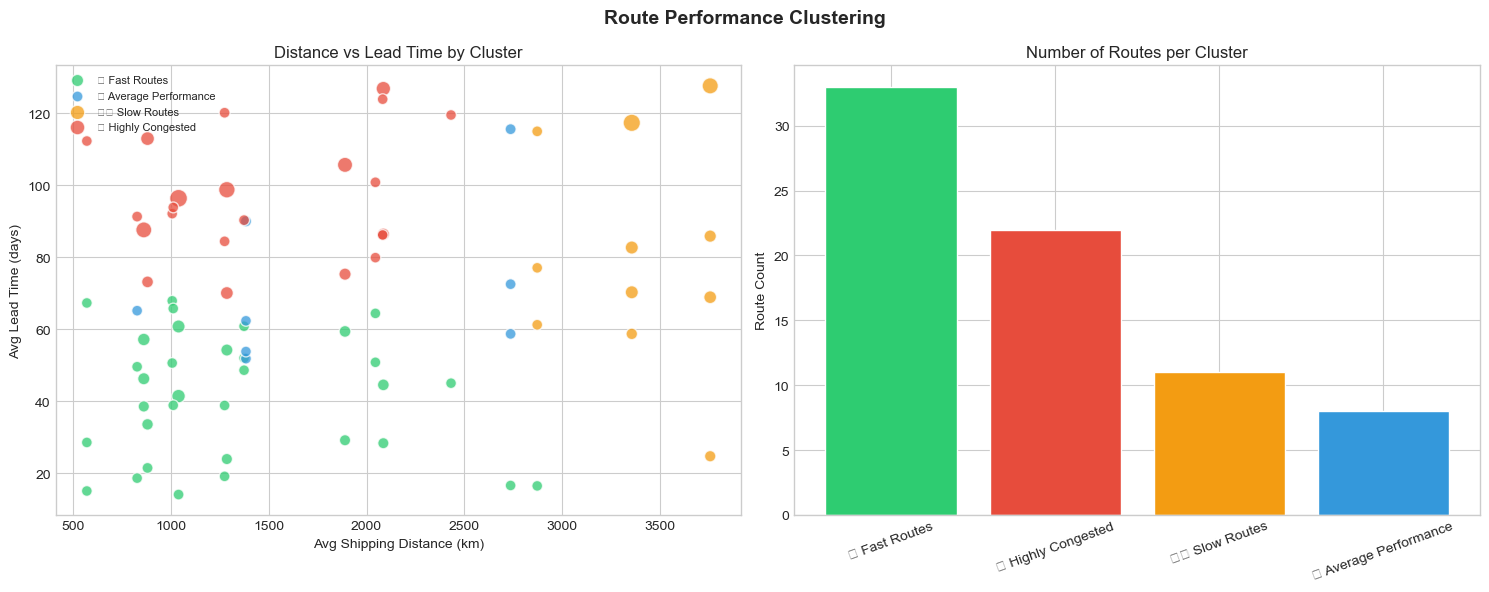

In [21]:
# ── Scatter: Distance vs Lead Time coloured by cluster ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Route Performance Clustering", fontsize=14, fontweight='bold')

cluster_colors = {0:'#2ECC71', 1:'#3498DB', 2:'#F39C12', 3:'#E74C3C'}

for cluster_id, group in route_df.groupby("Cluster"):
    label = cluster_labels[cluster_id]
    axes[0].scatter(group["Avg_Distance"], group["Avg_Lead_Time"],
                    c=cluster_colors[cluster_id], label=label,
                    s=60+group["Order_Count"]*0.1, alpha=0.75, edgecolors='white')

axes[0].set_xlabel("Avg Shipping Distance (km)")
axes[0].set_ylabel("Avg Lead Time (days)")
axes[0].set_title("Distance vs Lead Time by Cluster")
axes[0].legend(fontsize=8, loc='upper left')

# Cluster distribution bar
cluster_counts = route_df["Cluster_Label"].value_counts()
bar_colors = [cluster_colors[route_df[route_df["Cluster_Label"]==k]["Cluster"].iloc[0]] for k in cluster_counts.index]
axes[1].bar(cluster_counts.index, cluster_counts.values, color=bar_colors, edgecolor='white')
axes[1].set_title("Number of Routes per Cluster")
axes[1].set_ylabel("Route Count")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig("route_clusters.png", dpi=120, bbox_inches='tight')
plt.show()


##  Scenario Simulation Engine

In [22]:
ALL_FACTORIES = list(FACTORY_COORDS.keys())

def predict_lead_time(product_name, factory_name, region, ship_mode,
                      avg_units, avg_sales, avg_cost, avg_profit):
    """Predict lead time for a given product-factory-region-shipmode combination."""
    dist = haversine_km(
        FACTORY_COORDS[factory_name][0], FACTORY_COORDS[factory_name][1],
        REGION_COORDS[region][0],        REGION_COORDS[region][1]
    )
    base_days  = SHIP_MODE_DAYS[ship_mode]
    dist_x_sd  = dist * base_days
    margin     = avg_profit / (avg_sales + 1e-6)
    unit_val   = avg_sales / (avg_units + 1e-6)
    ship_x_div = label_encoders["Ship Mode"].transform([ship_mode])[0] * \
                 label_encoders["Division"].transform(
                     [df_clean[df_clean["Product Name"] == product_name]["Division"].iloc[0]])[0]

    row = np.array([[
        label_encoders["Ship Mode"].transform([ship_mode])[0],
        label_encoders["Region"].transform([region])[0],
        label_encoders["Division"].transform(
            [df_clean[df_clean["Product Name"] == product_name]["Division"].iloc[0]])[0],
        label_encoders["Factory"].transform([factory_name])[0],
        label_encoders["Product Name"].transform([product_name])[0],
        dist, base_days, dist_x_sd, margin, unit_val,
        avg_sales, avg_units, avg_cost, avg_profit, ship_x_div
    ]])
    return gb_model.predict(row)[0]


# ── Simulation loop ────────────────────────────────────────────────────────────
sim_records = []

for product, current_factory in FACTORY_MAP.items():
    product_data = df_clean[df_clean["Product Name"] == product]
    if len(product_data) == 0:
        continue

    avg_units  = product_data["Units"].mean()
    avg_sales  = product_data["Sales"].mean()
    avg_cost   = product_data["Cost"].mean()
    avg_profit = product_data["Gross Profit"].mean()

    for region in df_clean["Region"].unique():
        for ship_mode in df_clean["Ship Mode"].unique():
            current_lt = predict_lead_time(
                product, current_factory, region, ship_mode,
                avg_units, avg_sales, avg_cost, avg_profit)

            for alt_factory in ALL_FACTORIES:
                if alt_factory == current_factory:
                    continue
                alt_lt = predict_lead_time(
                    product, alt_factory, region, ship_mode,
                    avg_units, avg_sales, avg_cost, avg_profit)

                improvement_pct = ((current_lt - alt_lt) / current_lt) * 100

                sim_records.append({
                    "Product"            : product,
                    "Current_Factory"    : current_factory,
                    "Alt_Factory"        : alt_factory,
                    "Region"             : region,
                    "Ship_Mode"          : ship_mode,
                    "Current_Lead_Time"  : round(current_lt, 2),
                    "Alt_Lead_Time"      : round(alt_lt, 2),
                    "Improvement_Days"   : round(current_lt - alt_lt, 2),
                    "Improvement_Pct"    : round(improvement_pct, 2),
                    "Avg_Profit"         : round(avg_profit, 2),
                })

sim_df = pd.DataFrame(sim_records)
print(f"✅ Simulation complete: {len(sim_df):,} scenarios evaluated.")
print(f"   Scenarios with improvement > 0 : {(sim_df['Improvement_Pct'] > 0).sum():,}")
sim_df.head(5)


✅ Simulation complete: 960 scenarios evaluated.
   Scenarios with improvement > 0 : 504


,Product,Current_Factory,Alt_Factory,Region,Ship_Mode,Current_Lead_Time,Alt_Lead_Time,Improvement_Days,Improvement_Pct,Avg_Profit
0,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,Interior,Standard Class,98.59,105.57,-6.98,-7.08,9.31
1,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Sugar Shack,Interior,Standard Class,98.59,98.96,-0.37,-0.37,9.31
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Secret Factory,Interior,Standard Class,98.59,95.78,2.81,2.85,9.31
3,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,The Other Factory,Interior,Standard Class,98.59,100.16,-1.57,-1.59,9.31
4,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,Interior,First Class,54.64,55.19,-0.55,-1.00,9.31


##  Optimization & Recommendations


In [23]:
# ── Aggregate to product–factory level ────────────────────────────────────────
product_factory_agg = (sim_df
    .groupby(["Product", "Current_Factory", "Alt_Factory"])
    .agg(
        Avg_Improvement_Days =("Improvement_Days", "mean"),
        Avg_Improvement_Pct  =("Improvement_Pct",  "mean"),
        Min_Improvement_Pct  =("Improvement_Pct",  "min"),
        Avg_Profit           =("Avg_Profit",        "mean"),
        Scenario_Count       =("Improvement_Pct",  "count"),
    )
    .reset_index()
)

# ── Confidence Score: higher when consistently positive across scenarios ────────
product_factory_agg["Confidence_Score"] = (
    (product_factory_agg["Min_Improvement_Pct"] > 0).astype(float) * 0.4 +
    (product_factory_agg["Scenario_Count"] / product_factory_agg["Scenario_Count"].max()) * 0.3 +
    (product_factory_agg["Avg_Improvement_Pct"].clip(0, 30) / 30) * 0.3
).round(3)

# ── Filter: only recommendations with average improvement > 0 ─────────────────
recommendations = (product_factory_agg[product_factory_agg["Avg_Improvement_Pct"] > 0]
    .sort_values("Avg_Improvement_Pct", ascending=False)
    .reset_index(drop=True)
)

print(f"Candidate recommendations: {len(recommendations)}")
print("\nTop 15 by Average Improvement %:")
top15 = recommendations.head(15)[
    ["Product","Current_Factory","Alt_Factory",
     "Avg_Improvement_Pct","Avg_Improvement_Days",
     "Confidence_Score","Avg_Profit"]
].rename(columns={
    "Avg_Improvement_Pct" :"Improvement (%)",
    "Avg_Improvement_Days":"Saved (days)",
    "Confidence_Score"    :"Confidence",
    "Avg_Profit"          :"Avg Profit ($)"
})
print(top15.to_string(index=False))


Candidate recommendations: 21

Top 15 by Average Improvement %:
             Product Current_Factory       Alt_Factory  Improvement (%)  Saved (days)  Confidence  Avg Profit ($)
             Fun Dip     Sugar Shack The Other Factory         5.968125      3.271875       0.360            1.60
           SweeTARTS     Sugar Shack The Other Factory         5.481875      2.729375       0.355            2.87
         Laffy Taffy     Sugar Shack The Other Factory         5.386875      3.392500       0.354            3.35
             Fun Dip     Sugar Shack    Secret Factory         4.856875      1.779375       0.349            1.60
Fizzy Lifting Drinks     Sugar Shack The Other Factory         4.603750      3.358750       0.346            7.88
               Nerds     Sugar Shack The Other Factory         4.508125      2.600000       0.345            1.75
         Laffy Taffy     Sugar Shack    Secret Factory         3.921250      2.013750       0.339            3.35
               Nerds    

In [24]:
# ── Top recommendation per product ────────────────────────────────────────────
best_per_product = (recommendations
    .sort_values("Avg_Improvement_Pct", ascending=False)
    .groupby("Product")
    .first()
    .reset_index()
    .sort_values("Avg_Improvement_Pct", ascending=False)
)

print("=== TOP FACTORY REASSIGNMENT RECOMMENDATION PER PRODUCT ===\n")
for _, row in best_per_product.iterrows():
    print(f"📦 {row['Product']}")
    print(f"   Current Factory : {row['Current_Factory']}")
    print(f"   Recommended     : {row['Alt_Factory']}")
    print(f"   Avg Improvement : {row['Avg_Improvement_Pct']:+.1f}% ({row['Avg_Improvement_Days']:+.1f} days)")
    print(f"   Confidence Score: {row['Confidence_Score']:.2f}")
    print(f"   Avg Profit      : ${row['Avg_Profit']:.2f}")
    print()


=== TOP FACTORY REASSIGNMENT RECOMMENDATION PER PRODUCT ===

📦 Fun Dip
   Current Factory : Sugar Shack
   Recommended     : The Other Factory
   Avg Improvement : +6.0% (+3.3 days)
   Confidence Score: 0.36
   Avg Profit      : $1.60

📦 SweeTARTS
   Current Factory : Sugar Shack
   Recommended     : The Other Factory
   Avg Improvement : +5.5% (+2.7 days)
   Confidence Score: 0.35
   Avg Profit      : $2.87

📦 Laffy Taffy
   Current Factory : Sugar Shack
   Recommended     : The Other Factory
   Avg Improvement : +5.4% (+3.4 days)
   Confidence Score: 0.35
   Avg Profit      : $3.35

📦 Fizzy Lifting Drinks
   Current Factory : Sugar Shack
   Recommended     : The Other Factory
   Avg Improvement : +4.6% (+3.4 days)
   Confidence Score: 0.35
   Avg Profit      : $7.88

📦 Nerds
   Current Factory : Sugar Shack
   Recommended     : The Other Factory
   Avg Improvement : +4.5% (+2.6 days)
   Confidence Score: 0.34
   Avg Profit      : $1.75

📦 Wonka Gum
   Current Factory : Secret Factory

##  Recommendation Visualisations

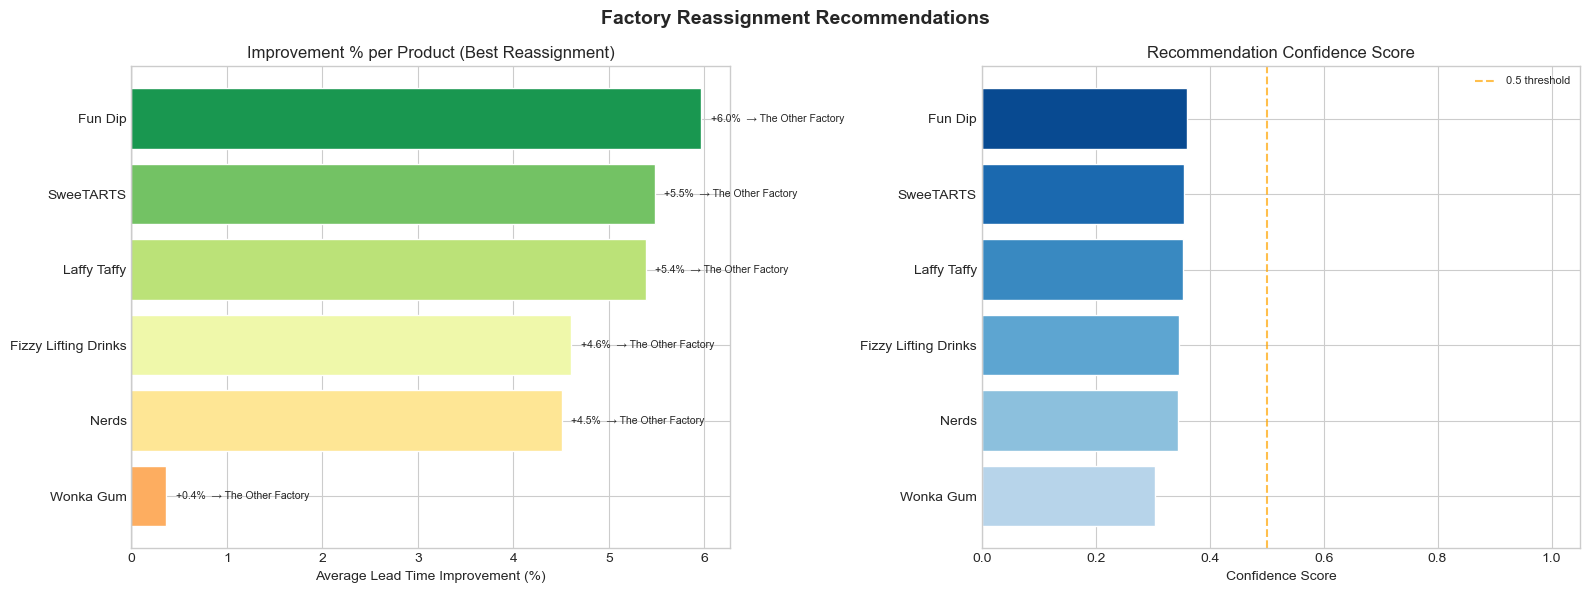

In [25]:
# ─── Top-N Improvement chart ───────────────────────────────────────────────────
top_n = best_per_product.head(10).sort_values("Avg_Improvement_Pct")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Factory Reassignment Recommendations", fontsize=14, fontweight='bold')

# Left: improvement %
color_vals = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_n)))
bars = axes[0].barh(top_n["Product"], top_n["Avg_Improvement_Pct"],
                    color=color_vals, edgecolor='white')
axes[0].set_xlabel("Average Lead Time Improvement (%)")
axes[0].set_title("Improvement % per Product (Best Reassignment)")
axes[0].axvline(0, color='black', linewidth=0.8)
for bar, val, alt in zip(bars, top_n["Avg_Improvement_Pct"], top_n["Alt_Factory"]):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'+{val:.1f}%  → {alt}', va='center', fontsize=7.5)

# Right: confidence score
color_conf = plt.cm.Blues(np.linspace(0.3, 0.9, len(top_n)))
axes[1].barh(top_n["Product"], top_n["Confidence_Score"],
             color=color_conf, edgecolor='white')
axes[1].set_xlabel("Confidence Score")
axes[1].set_title("Recommendation Confidence Score")
axes[1].set_xlim(0, 1.05)
axes[1].axvline(0.5, color='orange', linestyle='--', alpha=0.7, label='0.5 threshold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("recommendations.png", dpi=120, bbox_inches='tight')
plt.show()


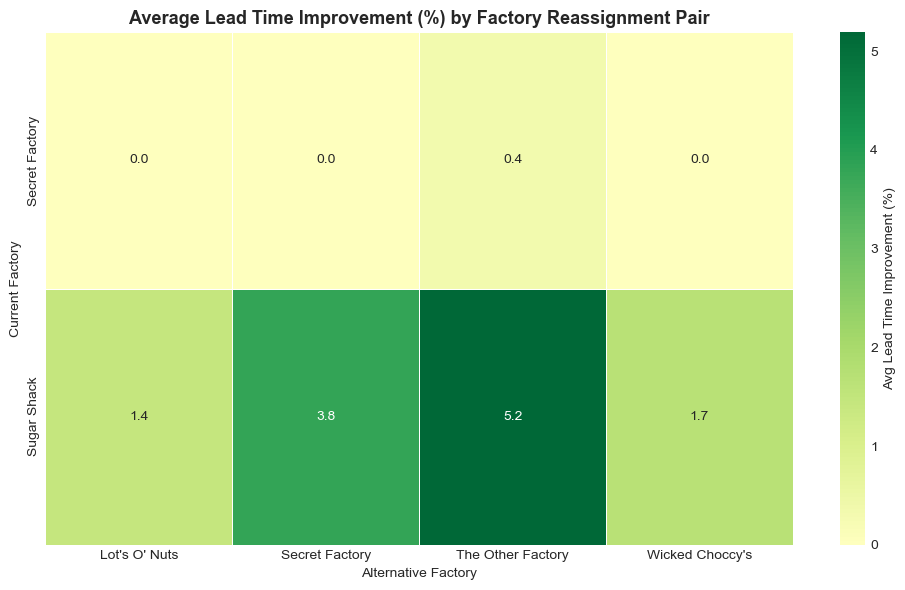

In [26]:
# ─── Heatmap: Average Improvement by Factory Pair ─────────────────────────────
pivot_improvement = (recommendations
    .groupby(["Current_Factory", "Alt_Factory"])["Avg_Improvement_Pct"]
    .mean()
    .reset_index()
    .pivot(index="Current_Factory", columns="Alt_Factory", values="Avg_Improvement_Pct")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_improvement, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Avg Lead Time Improvement (%)"})
ax.set_title("Average Lead Time Improvement (%) by Factory Reassignment Pair",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Alternative Factory")
ax.set_ylabel("Current Factory")
plt.tight_layout()
plt.savefig("factory_improvement_heatmap.png", dpi=120, bbox_inches='tight')
plt.show()


##  KPI Dashboard

In [27]:
# ─── Compute KPIs ─────────────────────────────────────────────────────────────
total_orders     = len(df_clean)
total_revenue    = df_clean["Sales"].sum()
total_profit     = df_clean["Gross Profit"].sum()
profit_margin    = (total_profit / total_revenue) * 100
avg_lead_time    = df_clean["Lead_Time_Days"].mean()
best_r2          = max(r2_lr, r2_rf, r2_gb)
products_covered = best_per_product["Product"].nunique()

top_improvement  = best_per_product["Avg_Improvement_Pct"].max()
avg_confidence   = recommendations["Confidence_Score"].mean()
slow_routes      = (route_df["Cluster"] >= 2).sum()

print("=" * 60)
print("     NASSAU CANDY DISTRIBUTOR — KPI DASHBOARD")
print("=" * 60)
print(f"  📦 Total Orders Analysed     : {total_orders:>10,}")
print(f"  💵 Total Revenue             : ${total_revenue:>12,.2f}")
print(f"  💰 Total Gross Profit        : ${total_profit:>12,.2f}")
print(f"  📈 Overall Profit Margin     : {profit_margin:>10.1f}%")
print(f"  ⏱  Avg Lead Time (days)      : {avg_lead_time:>10.1f}")
print("-" * 60)
print("  PREDICTIVE MODEL KPIs")
print(f"  🎯 Best Model R² Score       : {best_r2*100:>10.2f}%")
print(f"  🤖 Model Used for Simulation : {'Gradient Boosting':>10}")
print("-" * 60)
print("  OPTIMISATION KPIs")
print(f"  🚀 Max Lead Time Reduction   : {top_improvement:>10.1f}%")
print(f"  🛣  Slow / Congested Routes   : {slow_routes:>10}")
print(f"  📊 Avg Confidence Score      : {avg_confidence:>10.2f}")
print(f"  ✅ Products with Recommendation: {products_covered:>8}")
print("=" * 60)


     NASSAU CANDY DISTRIBUTOR — KPI DASHBOARD
  📦 Total Orders Analysed     :      9,992
  💵 Total Revenue             : $  139,205.09
  💰 Total Gross Profit        : $   91,695.06
  📈 Overall Profit Margin     :       65.9%
  ⏱  Avg Lead Time (days)      :       89.0
------------------------------------------------------------
  PREDICTIVE MODEL KPIs
  🎯 Best Model R² Score       :      91.72%
  🤖 Model Used for Simulation : Gradient Boosting
------------------------------------------------------------
  OPTIMISATION KPIs
  🚀 Max Lead Time Reduction   :        6.0%
  🛣  Slow / Congested Routes   :         33
  📊 Avg Confidence Score      :       0.33
  ✅ Products with Recommendation:        6


##  Save Best Model & Feature Columns with Joblib

In [28]:
# ════════════════════════════════════════════════════════════════
# 17. SAVE BEST MODEL & FEATURE COLUMNS WITH JOBLIB
# ════════════════════════════════════════════════════════════════
import joblib
import os

# ── Directory for saved artefacts ────────────────────────────────
SAVE_DIR = 'model_artefacts'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. Save best model (Gradient Boosting Regressor) ─────────────
model_path = os.path.join(SAVE_DIR, 'best_model_gradient_boosting.pkl')
joblib.dump(gb_model, model_path, compress=3)
print('Best model saved  :', model_path)
print('File size (KB)    :', round(os.path.getsize(model_path) / 1024, 1))

# ── 2. Save feature column list ──────────────────────────────────
feature_path = os.path.join(SAVE_DIR, 'feature_columns.pkl')
joblib.dump(FEATURE_COLS, feature_path)
print('Feature cols saved:', feature_path)
print('Columns:', FEATURE_COLS)

# ── 3. Save StandardScaler (needed for LR inference) ─────────────
scaler_path = os.path.join(SAVE_DIR, 'standard_scaler.pkl')
joblib.dump(scaler, scaler_path)
print('Scaler saved      :', scaler_path)

# ── 4. Round-trip verification ───────────────────────────────────
print('\n--- Round-trip verification ---')
loaded_model    = joblib.load(model_path)
loaded_features = joblib.load(feature_path)
y_pred_verify   = loaded_model.predict(X_test)
from sklearn.metrics import r2_score as r2
r2_verify = r2(y_test, y_pred_verify)
print('Loaded model type :', type(loaded_model).__name__)
print('Feature columns   :', loaded_features)
print('R2 after reload   :', round(r2_verify * 100, 2), '%')
print('Round-trip PASSED - model reloads and predicts correctly.')

# ── 5. Production usage snippet (printed for reference) ──────────
snippet = (
    'import joblib, pandas as pd\n'
    'model    = joblib.load("model_artefacts/best_model_gradient_boosting.pkl")\n'
    'features = joblib.load("model_artefacts/feature_columns.pkl")\n'
    'new_data = pd.DataFrame([your_input_dict])[features]\n'
    'predicted_lead_time = model.predict(new_data.values)\n'
    'print(predicted_lead_time[0])\n'
)
print('\n--- Production Usage Snippet ---')
print(snippet)


Best model saved  : model_artefacts/best_model_gradient_boosting.pkl
File size (KB)    : 152.7
Feature cols saved: model_artefacts/feature_columns.pkl
Columns: ['Ship Mode_enc', 'Region_enc', 'Division_enc', 'Factory_enc', 'Product Name_enc', 'Shipping_Distance_km', 'Base_Ship_Days', 'Distance_x_ShipDays', 'Profit_Margin', 'Unit_Value', 'Sales', 'Units', 'Cost', 'Gross Profit', 'Ship_x_Division']
Scaler saved      : model_artefacts/standard_scaler.pkl

--- Round-trip verification ---
Loaded model type : GradientBoostingRegressor
Feature columns   : ['Ship Mode_enc', 'Region_enc', 'Division_enc', 'Factory_enc', 'Product Name_enc', 'Shipping_Distance_km', 'Base_Ship_Days', 'Distance_x_ShipDays', 'Profit_Margin', 'Unit_Value', 'Sales', 'Units', 'Cost', 'Gross Profit', 'Ship_x_Division']
R2 after reload   : 91.72 %
Round-trip PASSED - model reloads and predicts correctly.

--- Production Usage Snippet ---
import joblib, pandas as pd
model    = joblib.load("model_artefacts/best_model_gradie